In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df=pd.read_csv("../Notebook/Data/customer_churn_dataset-training-master.csv")

In [3]:
test_df=pd.read_csv("../Notebook/Data/customer_churn_dataset-testing-master.csv")

In [4]:
df=pd.concat([train_df,test_df],axis=0).reset_index(drop=True)

In [5]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,64370.0,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505203,64371.0,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505204,64372.0,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505205,64373.0,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


In [6]:
for col in df.columns:
    print(f"{col}: {df[col].isnull().sum()}")

CustomerID: 1
Age: 1
Gender: 1
Tenure: 1
Usage Frequency: 1
Support Calls: 1
Payment Delay: 1
Subscription Type: 1
Contract Length: 1
Total Spend: 1
Last Interaction: 1
Churn: 1


In [7]:
df.dropna(inplace=True)

In [8]:
df.drop(columns=["CustomerID"],inplace=True)

In [9]:
df_copy=df.copy()

In [10]:
df_copy['Gender']=df_copy['Gender'].map({"Female":0,"Male":1})
df_copy['Subscription Type']=df_copy['Subscription Type'].map({"Basic":0,"Standard":1,"Premium":2})

In [11]:
df_copy['Contract Length']=df_copy['Contract Length'].map({'Annual':12,'Monthly':1,'Quarterly':6})

In [12]:
df_copy['Total_Usage_Frequency'] = df_copy["Contract Length"]*df_copy["Usage Frequency"]*df_copy["Tenure"]

In [13]:
df_copy

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Total_Usage_Frequency
0,30.0,0,39.0,14.0,5.0,18.0,1,12,932.0,17.0,1.0,6552.0
1,65.0,0,49.0,1.0,10.0,8.0,0,1,557.0,6.0,1.0,49.0
2,55.0,0,14.0,4.0,6.0,18.0,0,6,185.0,3.0,1.0,336.0
3,58.0,1,38.0,21.0,7.0,7.0,1,1,396.0,29.0,1.0,798.0
4,23.0,1,32.0,20.0,5.0,8.0,0,1,617.0,20.0,1.0,640.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,45.0,0,33.0,12.0,6.0,21.0,0,6,947.0,14.0,1.0,2376.0
505203,37.0,1,6.0,1.0,5.0,22.0,1,12,923.0,9.0,1.0,72.0
505204,25.0,1,39.0,14.0,8.0,30.0,2,1,327.0,20.0,1.0,546.0
505205,50.0,0,18.0,19.0,7.0,22.0,1,1,540.0,13.0,1.0,342.0


In [14]:
df_copy['Total_Usage_Frequency'] = df_copy["Contract Length"]*df_copy["Usage Frequency"]*df_copy["Tenure"]

In [15]:
#drop columns which are not needed
df_copy.drop(columns=["Contract Length","Usage Frequency","Tenure"],inplace=True)

In [16]:
df_copy

,Age,Gender,Support Calls,Payment Delay,Subscription Type,Total Spend,Last Interaction,Churn,Total_Usage_Frequency
0,30.0,0,5.0,18.0,1,932.0,17.0,1.0,6552.0
1,65.0,0,10.0,8.0,0,557.0,6.0,1.0,49.0
2,55.0,0,6.0,18.0,0,185.0,3.0,1.0,336.0
3,58.0,1,7.0,7.0,1,396.0,29.0,1.0,798.0
4,23.0,1,5.0,8.0,0,617.0,20.0,1.0,640.0
...,...,...,...,...,...,...,...,...,...
505202,45.0,0,6.0,21.0,0,947.0,14.0,1.0,2376.0
505203,37.0,1,5.0,22.0,1,923.0,9.0,1.0,72.0
505204,25.0,1,8.0,30.0,2,327.0,20.0,1.0,546.0
505205,50.0,0,7.0,22.0,1,540.0,13.0,1.0,342.0


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X=df_copy.drop("Churn",axis=1)
y=df_copy["Churn"]

In [19]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
X_train.shape,Y_train.shape,X_test.shape,Y_test.shape

((404164, 8), (404164,), (101042, 8), (101042,))

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.model_selection import GridSearchCV

In [22]:
LG=LogisticRegression()

In [23]:
LG.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
Y_pred=LG.predict(X_test)

In [25]:
accuracy_score(Y_test,Y_pred)# accuracy score is 82%

0.8218364640446547

In [26]:
def coeff_check(model,features):
    coeff_df=pd.DataFrame(model.coef_[0],index=features.columns,columns=["Coefficient"])
    coeff_df["abs"]=coeff_df["Coefficient"].abs()
    coeff_df.sort_values(by="abs",ascending=False,inplace=True)
    return coeff_df.drop(columns=["abs"] )

In [27]:
coeff_check(LG,X)

,Coefficient
Gender,-0.678291
Support Calls,0.415252
Subscription Type,-0.250756
Payment Delay,0.079511
Last Interaction,0.029461
Age,0.019064
Total Spend,-0.003556
Total_Usage_Frequency,-0.000088


Logistic Regression got 82% accuracy ,before any hyperparameter tunning

In [28]:
#lets try different different  models now
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [29]:
models={"logistic_regression":LogisticRegression(),
        "Random forest":RandomForestClassifier(),
        "Decision Tree":DecisionTreeClassifier(),
        "XGBoost":XGBClassifier(),
        }

In [30]:
from sklearn.metrics import recall_score,precision_score

In [31]:
def evaluate_model(models: dict) -> pd.DataFrame:
    accuracy_scores = []
    model_names = []
    recall_scores = []
    precision_scores = []

    for name, model in models.items():
        model.fit(X_train, Y_train)
        y_pred = model.predict(X_test)

        accuracy_scores.append(accuracy_score(Y_test, y_pred))
        recall_scores.append(recall_score(Y_test, y_pred))
        precision_scores.append(precision_score(Y_test, y_pred))

        model_names.append(name)

    return pd.DataFrame({
        "Model": model_names,
        "Accuracy": accuracy_scores,
        "Recall": recall_scores,
        "Precision": precision_scores
    })


In [72]:
evaluate_model(models)

,Model,Accuracy,Recall,Precision
0,logistic_regression,0.821836,0.831862,0.844669
1,Random forest,0.923715,0.975669,0.896070
2,Decision Tree,0.863156,0.869660,0.882042
3,XGBoost,0.923200,0.974278,0.896319


Reports:

Random Forest and XGBoost are Performing better then logistic regression,and Decision Tree



which metrics should we prefer more?

1.) Recall 

2.) Precision

3.) F1score

Precison metrics should be our main focus,because we dont want to miss any  customer who has chance or in risk zone for churn

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10]}

In [36]:
Randomforest_Tunning=GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid,cv=5,n_jobs=-1)

In [37]:
Randomforest_Tunning.fit(X_train,Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [39]:
Randomforest_Tunning.best_params_

{'max_depth': 10, 'n_estimators': 300}

In [40]:
Randomforest_Tunning.best_score_

np.float64(0.9197875172262385)

In [42]:
y_test_pred=Randomforest_Tunning.best_estimator_.score(X_test,Y_test)

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

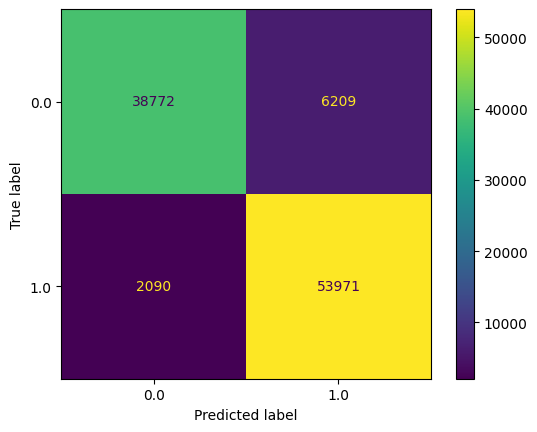

In [45]:
ConfusionMatrixDisplay.from_estimator(Randomforest_Tunning.best_estimator_,X_test,Y_test)

In [46]:
precision_score(Y_test,Randomforest_Tunning.best_estimator_.predict(X_test))

0.8968261881023596

In [ ]:
recall_score(Y_test,Randomforest_Tunning.best_estimator_.predict(X_test))

0.9627191808922424

In [48]:
#using random serach cv

In [49]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=10,   # only 10 combos instead of full grid
    cv=3,
    n_jobs=-1,
    random_state=42
)

In [50]:
random_search.fit(X_train, Y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... vers

In [52]:
random_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': None}

In [53]:
random_search.best_score_

np.float64(0.9252234259534635)

In [54]:
random_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': None}

Lets Tune now,Precision for our model

In [55]:
#building model with best params from random search cv
RF=RandomForestClassifier(**random_search.best_params_)
RF.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [57]:
Y_Pred=RF.predict(X_test)

In [ ]:
accuracy_score(Y_test,Y_Pred)# test accuracy is 92%

0.9239623127016489

In [59]:
Y_pred_train=RF.predict(X_train)

In [61]:
accuracy_score(Y_train,Y_pred_train)# train accuracy is 93% ,which means model is not overfitting and is generalizing well on unseen data.

0.9314263516790214

In [63]:
y_proba=RF.predict_proba(X_test)[:,1]

In [64]:
from sklearn.metrics import precision_recall_curve

In [65]:
tpr,fpr,thresholds=precision_recall_curve(Y_test,y_proba)

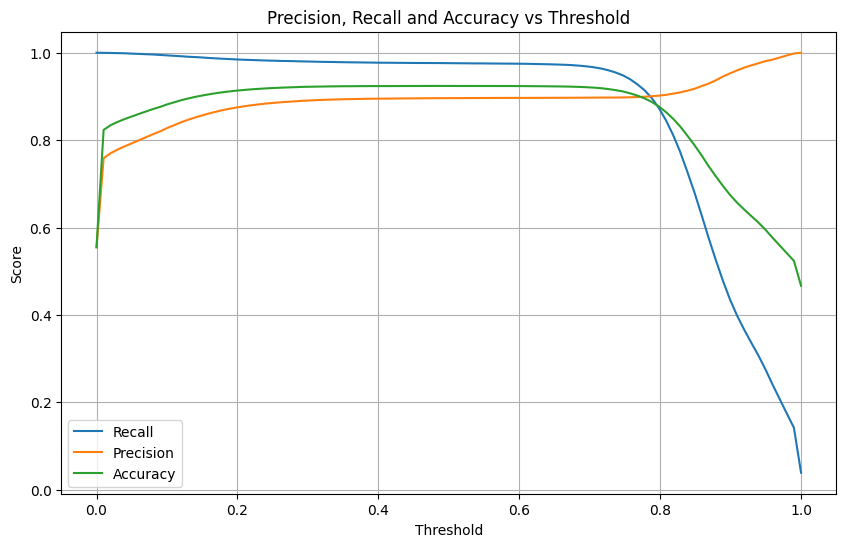

In [67]:
threshold=np.linspace(0,1,100)
recall_scores=[]
precision_scores=[]
accuracy_scores=[]
for thresh in threshold:
    y_pred_thresh=(y_proba>=thresh).astype(int)
    recall_scores.append(recall_score(Y_test,y_pred_thresh))
    precision_scores.append(precision_score(Y_test,y_pred_thresh))
    accuracy_scores.append(accuracy_score(Y_test,y_pred_thresh))
plt.figure(figsize=(10,6))
plt.plot(threshold,recall_scores,label="Recall")
plt.plot(threshold,precision_scores,label="Precision")
plt.plot(threshold,accuracy_scores,label="Accuracy")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and Accuracy vs Threshold")
plt.legend()
plt.grid()


LETS Set the threshold value to 0.8 an then check precision score

In [68]:
new_proba=np.where(y_proba>=0.8,1,0)

In [70]:
#check accuracy, precision and recall at threshold 0.8
def check_metrics_at_threshold(Threshold):
    y_pred_thresh=np.where(y_proba>=Threshold,1,0)
    acc=accuracy_score(Y_test,y_pred_thresh)
    prec=precision_score(Y_test,y_pred_thresh)
    rec=recall_score(Y_test,y_pred_thresh)
    print(f"At threshold {Threshold}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")
    return acc,prec,rec




In [76]:
check_metrics_at_threshold(0.8)

At threshold 0.8: Accuracy=0.8750, Precision=0.9021, Recall=0.8690


(0.8749925773440748, 0.9020998444559662, 0.8689998394605876)

better to go with without tuned model,cuz Precision score doesn't chnge much and also it drops accuracy score and recall score sgnificantly


Conclusion:


Best model-->RandomForest Classifier()

Best Params for our model --> {'n_estimators': 300,
 'min_samples_split': 10,

 'min_samples_leaf': 1,

 'max_features': 'log2',
 
 'max_depth': None}

Accuracy,Precision,Recall - 92% , 89% ,96%


